In [1]:
import numpy as np
import h5py
import corner
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
data = h5py.File('sample_2e7_design_precessing_higherordermodes_3detectors.h5', 'r')

In [3]:
data.keys()

<KeysViewHDF5 ['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'det', 'iota', 'mtot', 'psi', 'q', 'ra', 'snr', 'z']>

In [4]:
# def read(x):
#     matrix = {}
#     for key in x.keys():
#         matrix[key] = np.array(x[key])
#     return matrix
    
def read(x):
    return {key: x[key][()] for key in x.keys()}

In [5]:
dataset = read(data)

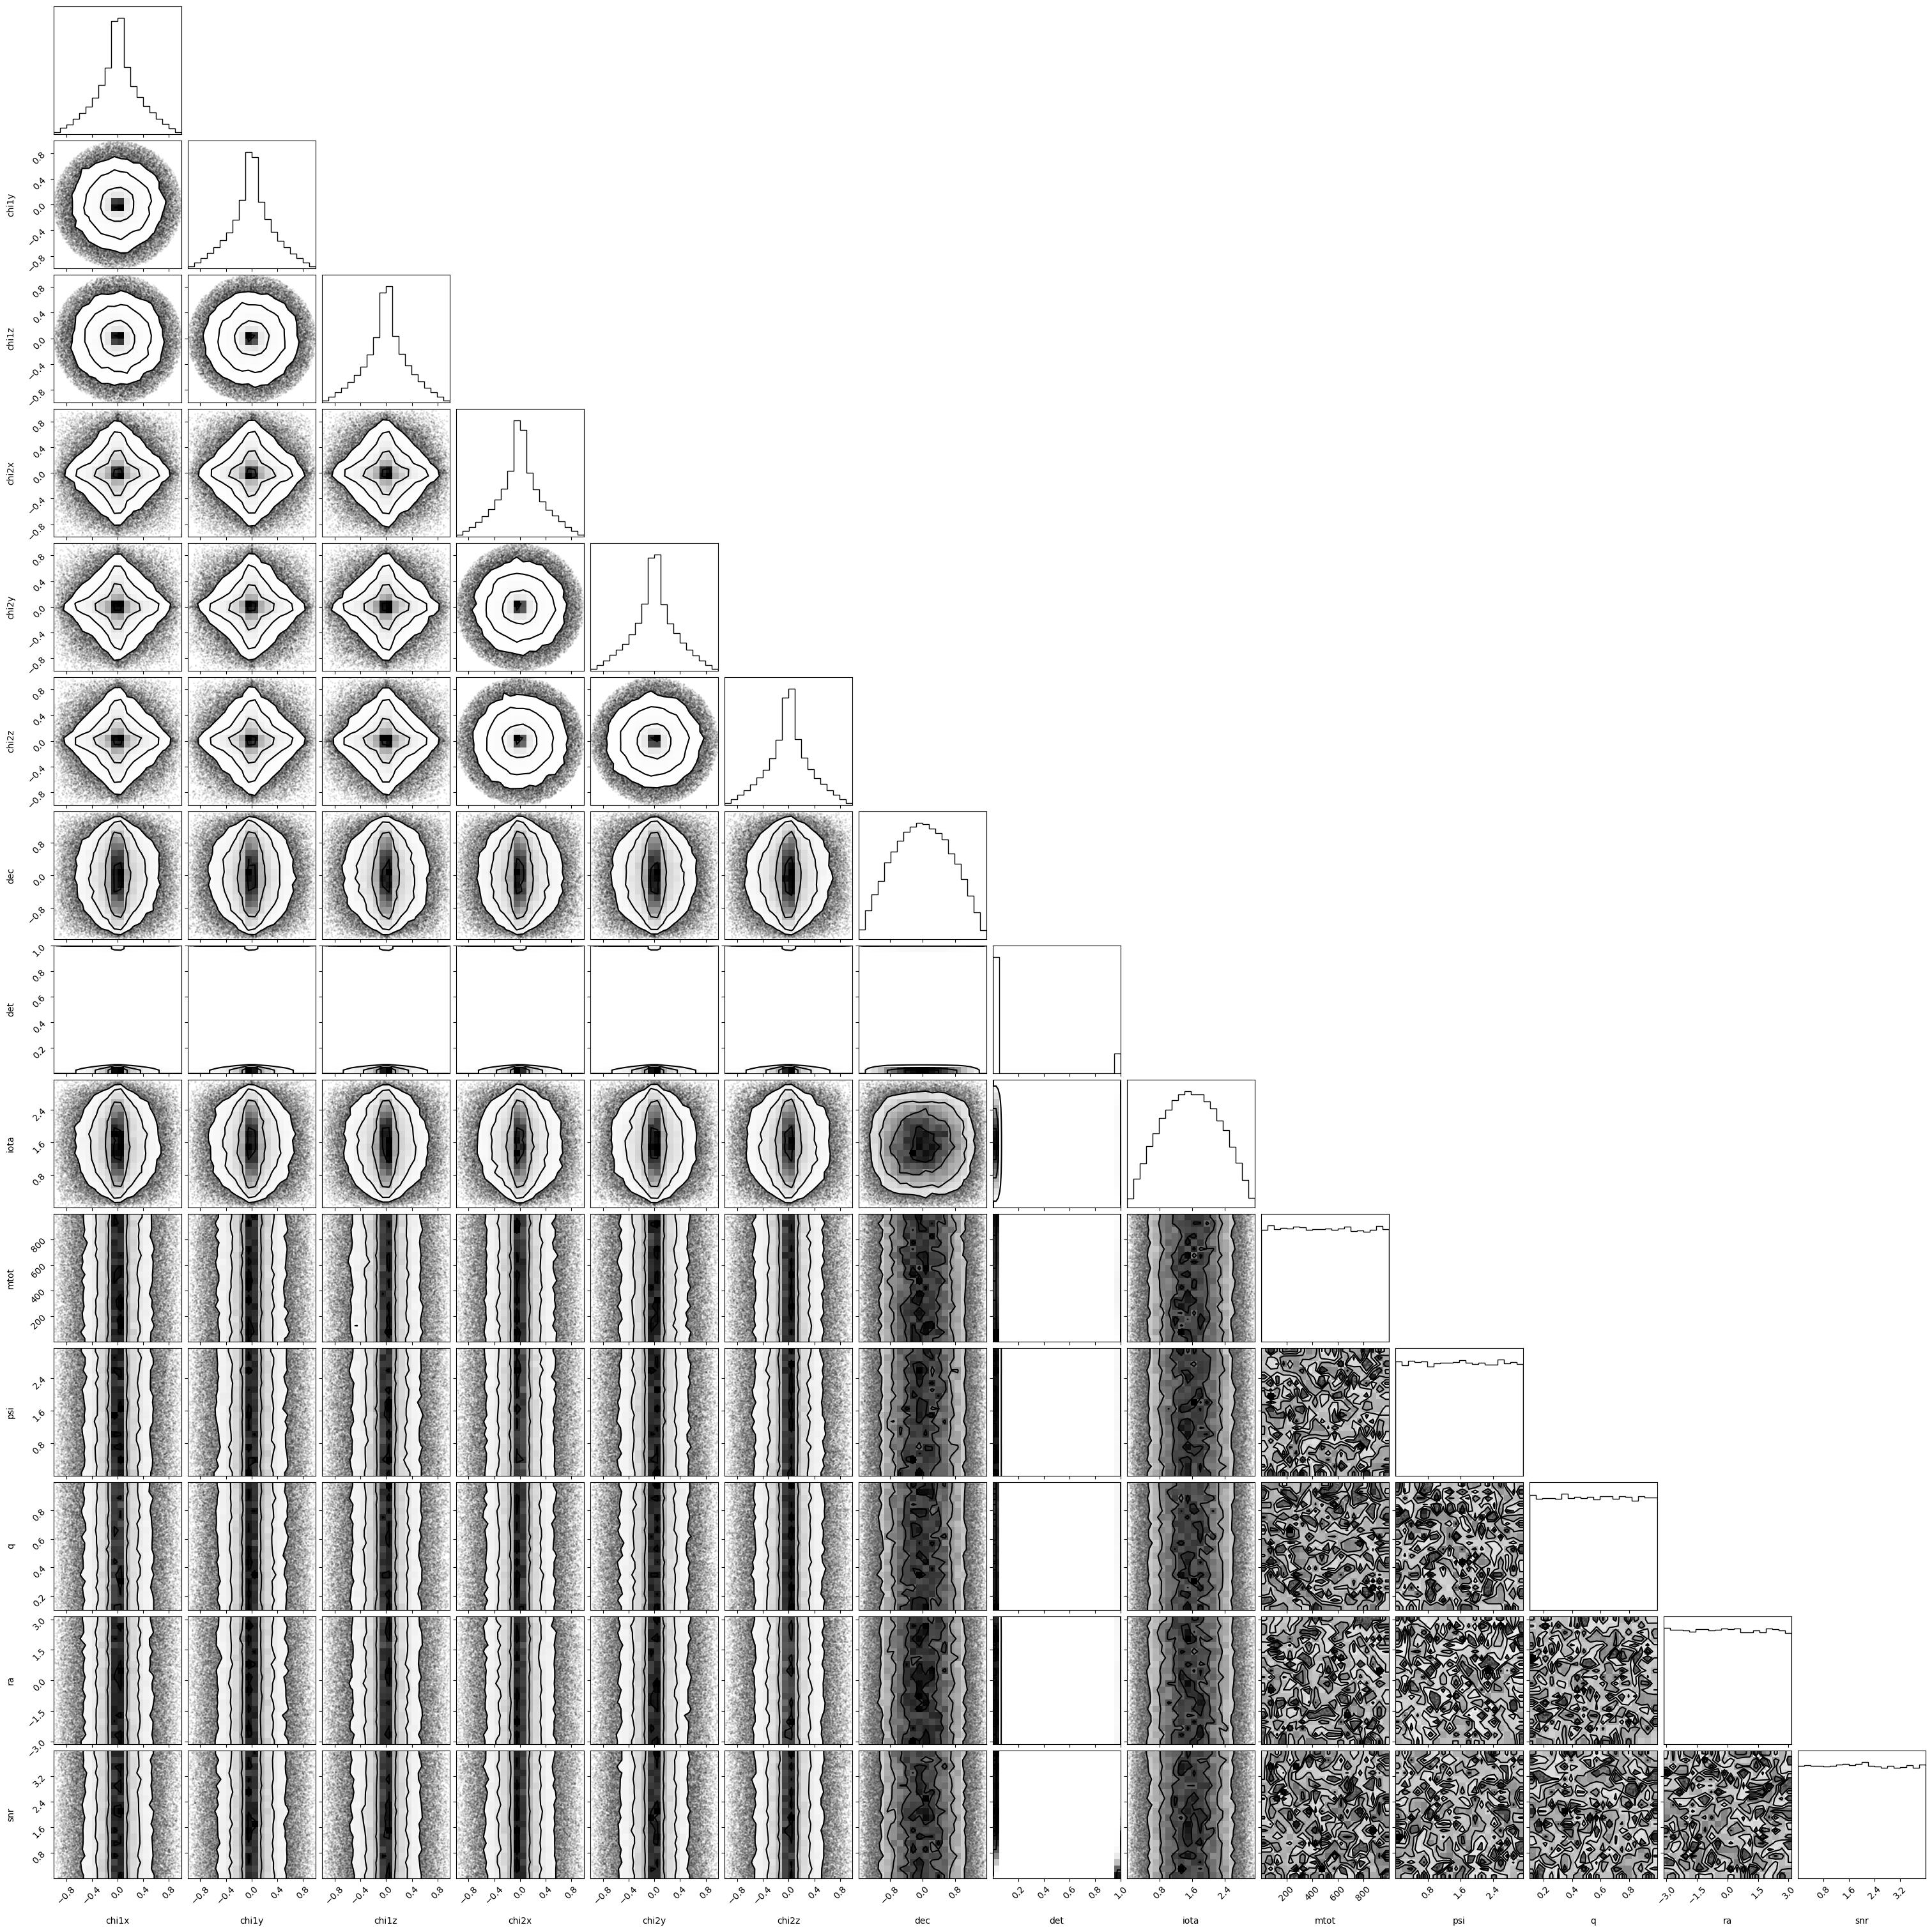

In [6]:
s = 100000 #number data i take into consideration for first analyses

prova = np.column_stack([
    dataset['chi1x'][:s],
    dataset['chi1y'][:s],
    dataset['chi1z'][:s],
    dataset['chi2x'][:s],
    dataset['chi2y'][:s],
    dataset['chi2z'][:s],
    dataset['dec'][:s],
    dataset['det'][:s],
    dataset['iota'][:s],
    dataset['mtot'][:s],
    dataset['psi'][:s],
    dataset['q'][:s],
    dataset['ra'][:s],
    # dataset['snr'][:s],
    dataset['z'][:s]
])


figure = corner.corner(prova, labels=['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'det', 'iota', 'mtot', 'psi', 'q', 'ra', 'snr', 'z'])

In [7]:
snr =  dataset['snr'][:s]
snr_label = (dataset['snr'][:s] > 12).astype(bool)
scaler = StandardScaler()
prova_t = scaler.fit_transform(prova)

In [ ]:
prova_train, prova_test, snr_train, snr_test = train_test_split(prova_t, snr_label, test_size = 0.2)


bag_clf = BaggingClassifier(
    DecisionTreeClassifier(random_state=42), 
    n_estimators=500, max_samples=100, 
    bootstrap=True, random_state=42, n_jobs=-1)

print(snr_train)
bag_clf.fit(prova_train, snr_train)
snr_pred = bag_clf.predict(prova_test)



[False False False ... False False False]


In [ ]:

accuracy_score(snr_test, snr_pred)

1.0

pretty good, now on all set

In [ ]:

prova = np.column_stack([
    dataset['chi1x'],
    dataset['chi1y'],
    dataset['chi1z'],
    dataset['chi2x'],
    dataset['chi2y'],
    dataset['chi2z'],
    dataset['dec'],
    dataset['det'],
    dataset['iota'],
    dataset['mtot'],
    dataset['psi'],
    dataset['q'],
    dataset['ra'],
    # dataset['snr'],
    dataset['z']
])

snr =  dataset['snr']
snr_label = (dataset['snr'] > 12).astype(bool)
scaler = StandardScaler()

prova_t = scaler.fit_transform(prova)

: 

In [ ]:
prova_train, prova_test, snr_train, snr_test = train_test_split(prova_t, snr_label, test_size = 0.2)



print(snr_train)
bag_clf.fit(prova_train, snr_train)
snr_pred = bag_clf.predict(prova_test)



In [ ]:
accuracy_score(snr_test, snr_pred)